In [12]:
#----VIP-PLS-Spectra-SNV----#
import os
import sys
from pathlib import Path
project_root = Path('/home/liudaolong/Project/07-Honey')
sys.path.append(str(project_root))

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import PLSRegression

from utils import datalodaer,preprocess

plt.rcParams.update({
    'font.family': 'Times New Roman',
    'font.size': 8,
    'axes.titlesize': 9,
    'axes.labelsize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'figure.dpi': 600,
    'svg.fonttype': 'none'
})
%matplotlib inline
%config InlineBackend.figure_format = 'svg'

In [13]:
# 定义预处理方法字典
preprocess_methods = {
    "Raw":          preprocess.DummyTransformer(),  # 原始数据
    "Detrend":      preprocess.Detrend(type='linear'), # 线性基线校正
    "SNV":          preprocess.SNV(),               # 标准正态变量变换
    "MSC":          preprocess.MSC(),               # 多元散射校正
    "SG_1":         preprocess.SavitzkyGolay(window_length=15, polyorder=3, deriv=1), # 一阶导
    "SG_2":         preprocess.SavitzkyGolay(window_length=15, polyorder=3, deriv=2)  # 二阶导
}

prep_obj = preprocess_methods["SNV"]

In [14]:
spectra_path = project_root / 'data/spectra/Spectra_TS_wavelength.csv'
image_features_path = project_root / 'data/pictures/lab_features.csv'
label_path = project_root / 'data/labels/5-HMF.csv'


In [15]:
def extract_all_feature_names(spectra_path, image_features_path):
    """
    提取并验证所有特征名称，包括合并后的完整特征列表
    
    参数:
        spectra_path (str): 光谱数据文件路径
        image_features_path (str): 图像特征数据文件路径
    
    返回:
        dict: 包含各种特征名称的字典
    """
    # 读取列名
    spectra_columns = pd.read_csv(spectra_path, nrows=0).columns.tolist()
    image_columns = pd.read_csv(image_features_path, nrows=0).columns.tolist()
    
    # 提取特征名称
    spectra_wavelengths = spectra_columns[2:]  # 跳过第一列（"名称"）
    image_feature_names = image_columns[1:]    # 跳过第一列（"名称"）
    
    # 验证光谱特征数量（可选）
    print(f"光谱特征数量: {len(spectra_wavelengths)}")
    print(f"图像特征数量: {len(image_feature_names)}")
    
    # 创建合并后的特征名称列表（模拟fused_data_split中的合并顺序）
    all_feature_names = spectra_wavelengths + image_feature_names
    
    return {
        'spectra_wavelengths': spectra_wavelengths,
        'image_feature_names': image_feature_names,
        'all_features': all_feature_names,
        'spectra_count': len(spectra_wavelengths),
        'image_count': len(image_feature_names),
        'total_features': len(all_feature_names)
    }

feature_names_dic = extract_all_feature_names(spectra_path, image_features_path)
all_features = feature_names_dic['all_features']
wavelength = feature_names_dic['spectra_wavelengths']
image_feature_names = feature_names_dic['image_feature_names']
image_count =feature_names_dic['image_count']
print(f'spectra_count: {feature_names_dic['spectra_count']}')
print(f'image_count: {feature_names_dic['image_count']}')
print(f'total_features: {feature_names_dic['total_features']}')


光谱特征数量: 2075
图像特征数量: 3
spectra_count: 2075
image_count: 3
total_features: 2078


In [16]:

train_set, val_set, test_set = datalodaer.data_split(spectra_path, label_path)
# 用于训练PLS
X2train_without_prep = np.concatenate([train_set[0], val_set[0]], axis=0)
X2train = prep_obj.fit_transform(X2train_without_prep)
y2train = np.concatenate([train_set[1], val_set[1]], axis=0)



In [17]:
def compute_vip(pls, X, y):
    """
    pls: fitted sklearn.cross_decomposition.PLSRegression
    X: array (n_samples, p)
    y: array (n_samples,) or (n_samples, 1)
    """
    if y.ndim == 1:
        y = y.reshape(-1, 1)

    T = pls.x_scores_          # (n, A)
    W = pls.x_weights_         # (p, A)
    Q = pls.y_loadings_        # (1, A) or (m, A)

    p, A = W.shape

    # SSY explained by each component a
    # SSY_a = sum_i (t_ia * q_a)^2
    # For single-response regression:
    SSY = np.sum((T @ Q.T) ** 2, axis=0)  # length A

    vip = np.zeros((p,))
    Wnorm2 = np.sum(W ** 2, axis=0)  # length A

    for j in range(p):
        vip[j] = np.sqrt(p * np.sum(SSY * (W[j, :] ** 2) / (Wnorm2 + 1e-12)) / (np.sum(SSY) + 1e-12))
    return vip

In [18]:
def train_and_compute_vip(X_train, y_train, n_components=13):
    """简单的训练和VIP计算组合"""
    # 1. 定义并训练Pipeline
    steps = [
        ("scaler", StandardScaler()),
        ("pls", PLSRegression(n_components=n_components))
    ]
    pipe = Pipeline(steps)
    pipe.fit(X_train, y_train)
    
    # 2. 获取标准化后的数据和PLS模型
    X_scaled = pipe.named_steps["scaler"].transform(X_train)
    pls_model = pipe.named_steps["pls"]
    
    # 3. 计算VIP
    vip = compute_vip(pls_model, X_scaled, y_train)
    
    return pipe, vip


In [19]:
# 训练并计算VIP
trained_pipe, vip_scores = train_and_compute_vip(X2train, y2train, n_components=13)

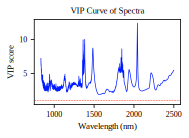

In [20]:
wavelengths_nm = np.array([float(c) for c in wavelength], dtype=float)
vip_threshold=1.0
title="VIP Curve of Spectra"
outpath="01-VIP-PLS-Spectra-SNV.svg"

cm_to_inch = 1/2.54  # 厘米转英寸的转换因子
width_inch = 7 * cm_to_inch
height_inch = 5 * cm_to_inch

plt.figure(figsize=(width_inch, height_inch), dpi=600)
plt.plot(wavelengths_nm, vip_scores, linewidth=0.7,color="#001BFF")
plt.axhline(vip_threshold, linestyle="--", linewidth=0.5, color="#FD1702E0" )
plt.xlabel("Wavelength (nm)")
plt.ylabel("VIP score")
plt.title(title)
plt.tight_layout()
plt.savefig(outpath,
            format='svg',
            dpi=600,
            bbox_inches='tight')
plt.show()

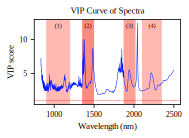

In [38]:
fig, ax = plt.subplots(figsize=(width_inch, height_inch), dpi=600)
plt.plot(wavelengths_nm, vip_scores, linewidth=0.5, color="#001BFF")
plt.axhline(vip_threshold, linestyle="--", linewidth=0.5, color="#FD1702E0")
plt.xlabel("Wavelength (nm)")
plt.ylabel("VIP score")
regions = [
    (900, 1200, "(1)", 0.3),  # "2nd overtone (O–H/C–H)"
    (1350, 1500, "(2)", 0.5),  # "O–H (water)"
    (1870, 2020, "(3)", 0.4),  # "O–H combination (water)"
    (2100, 2350, "(4)", 0.3),  # "C–H/O–H/C–O combinations"
    # (2200, 2300, '', 0.6),
]
y0, y1 = ax.get_ylim()
text_y = y1 - 0.05 * (y1 - y0)

for (x0, x1, lab, a) in regions:
    left, right = (x0, x1) if x0 < x1 else (x1, x0)
    ax.axvspan(left, right, alpha=a, color="#FD1702E0", linewidth=0, zorder=0)
    ax.text((left + right) / 2, text_y, lab,
            ha="center", va="top", fontsize=6, color="k")

plt.title(title)
plt.tight_layout()
plt.savefig(outpath,
            format='svg',
            dpi=600,
            bbox_inches='tight')
plt.show()

In [ ]:
"2nd overtone (O–H/C–H)"
"O–H (water)"
"O–H combination (water)"
"C–H/O–H/C–O combinations"